# Phase 3: Feature Engineering + Deep Dive on Top Models
**Project:** ML-2 Fraud Detection System  
**Date:** 2026-04-29  
**Researcher:** Anthony Rodrigues  

## Objective
Phase 2 established CatBoost as champion (AUPRC=0.8872) using 17 instantaneous features.
All 17 features describe the *current transaction* — none capture cardholder behavioral patterns.

**Question:** Can we beat CatBoost's 0.8872 AUPRC by engineering behavioral features that real fraud systems use?

## Research
1. **Albahnsen et al. (2016)** — Transaction aggregation + periodic (von Mises) features boosted savings by 13%.
   Key insight: aggregate by card → count + amount in look-back windows.
2. **NVIDIA/Kaggle IEEE-CIS 1st place (Chris Deotte)** — Group aggregation features were the #1 differentiator.
   UID construction → rolling counts + amounts → massive lift over raw features.
3. **MDPI 2024 (Hybrid Feature Engineering)** — Customer spending behavior features outperform static features.

## Feature Groups to Engineer
| Group | Features | Rationale |
|-------|----------|-----------|
| Velocity | txn count in 1h/6h/24h/7d per card | Fraud bursts: stolen cards used rapidly |
| Amount deviation | z-score vs card mean, ratio to rolling avg | Unusual spend amounts signal compromise |
| Temporal behavior | time since last txn, deviation from typical hour | Behavioral anomaly detection |
| Geographic | distance from card centroid, impossible travel | Physical impossibility = fraud signal |
| Category risk | historical fraud rate per category, per card-category | High-risk merchant categories |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
import gc
from pathlib import Path
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_score, recall_score, precision_recall_curve,
                             confusion_matrix)
from sklearn.preprocessing import LabelEncoder

DATA_PATH = Path('../data/raw/fraud_transactions.csv')
RESULTS_DIR = Path('../results')
RNG = 42

print('Libraries loaded')

Libraries loaded


## 1. Load Raw Data + Phase 2 Baseline Features
We reload from raw CSV to access `cc_num` and `trans_date_trans_time` — needed for behavioral feature engineering.

In [2]:
t0 = time.time()
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows in {time.time()-t0:.1f}s')
print(f'Columns: {list(df.columns)}')
print(f'Fraud rate: {df["is_fraud"].mean():.4f} ({df["is_fraud"].sum():,} / {len(df):,})')

Loaded 1,048,575 rows in 1.2s
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Fraud rate: 0.0057 (6,006 / 1,048,575)


In [3]:
# Parse timestamps and sort chronologically (required for temporal features)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)
print(f'Date range: {df["trans_date_trans_time"].min()} → {df["trans_date_trans_time"].max()}')
print(f'Unique cards: {df["cc_num"].nunique():,}')
print(f'Unique merchants: {df["merchant"].nunique():,}')
print(f'Categories: {df["category"].nunique()}')

Date range: 2019-01-01 00:00:00 → 2020-03-10 16:08:00
Unique cards: 943
Unique merchants: 693
Categories: 14


## 2. Rebuild Phase 2 Baseline Features (17 features)
Reproduce the exact same feature set for apples-to-apples comparison.

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Phase 2 features
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['distance_km'] = haversine(df['lat'].values, df['long'].values,
                               df['merch_lat'].values, df['merch_long'].values)
df['gender'] = (df['gender'] == 'M').astype(int)
le_cat = LabelEncoder()
df['category_encoded'] = le_cat.fit_transform(df['category'])
df['log_amt'] = np.log1p(df['amt'])
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

BASELINE_FEATURES = [
    'amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time',
    'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month',
    'is_weekend', 'age', 'distance_km', 'category_encoded',
    'log_amt', 'is_night',
]
print(f'Baseline features: {len(BASELINE_FEATURES)}')
print(BASELINE_FEATURES)

Baseline features: 17


['amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'is_weekend', 'age', 'distance_km', 'category_encoded', 'log_amt', 'is_night']


## 3. Engineer Behavioral Features

### Group A: Transaction Velocity (per card, look-back windows)
How many transactions did this card make in the last 1h, 6h, 24h, 7d? 
Stolen cards show burst patterns — many txns in short windows.

In [5]:
t0 = time.time()

# Convert to unix timestamp for efficient windowed lookups
df['ts'] = df['trans_date_trans_time'].astype(np.int64) // 10**9

# Sort by card + time for per-card rolling computations
df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

# For each card, compute count and sum of amt in look-back windows
# Using vectorized groupby + rolling on timestamp index
windows = {'1h': 3600, '6h': 21600, '24h': 86400, '7d': 604800}

# Pre-compute per-card using groupby iteration (vectorized within groups)
velocity_count = {w: np.zeros(len(df)) for w in windows}
velocity_amt = {w: np.zeros(len(df)) for w in windows}

card_groups = df.groupby('cc_num')
n_cards = len(card_groups)
for i, (card, grp) in enumerate(card_groups):
    if i % 200 == 0:
        print(f'  velocity: card {i:,}/{n_cards:,} ({i/n_cards*100:.0f}%)', end='\r')
    idx = grp.index.values
    ts_arr = grp['ts'].values
    amt_arr = grp['amt'].values
    n = len(ts_arr)
    
    for wname, wsec in windows.items():
        counts = np.zeros(n)
        sums = np.zeros(n)
        left = 0
        running_sum = 0.0
        for j in range(n):
            # Move left pointer: exclude transactions older than window
            while left < j and ts_arr[j] - ts_arr[left] > wsec:
                running_sum -= amt_arr[left]
                left += 1
            # Count = j - left (exclude current txn itself)
            counts[j] = j - left
            sums[j] = running_sum
            running_sum += amt_arr[j]
        velocity_count[wname][idx] = counts
        velocity_amt[wname][idx] = sums

for wname in windows:
    df[f'vel_count_{wname}'] = velocity_count[wname]
    df[f'vel_amt_{wname}'] = velocity_amt[wname]

print(f'\nVelocity features computed in {time.time()-t0:.1f}s')
print(f'Velocity count 24h — mean: {df["vel_count_24h"].mean():.2f}, max: {df["vel_count_24h"].max():.0f}')
print(f'Velocity amt 24h — mean: {df["vel_amt_24h"].mean():.2f}, max: {df["vel_amt_24h"].max():.2f}')


Velocity features computed in 2.3s
Velocity count 24h — mean: 4.05, max: 36
Velocity amt 24h — mean: 286.99, max: 29773.37


### Group B: Amount Deviation (per card)
Z-score of current amount vs the card's historical spending. Compromised cards often show amounts far from the cardholder's norm.

In [6]:
t0 = time.time()

# Per-card expanding mean and std of amt (only using past transactions)
amt_exp_mean = np.zeros(len(df))
amt_exp_std = np.zeros(len(df))
amt_ratio_to_mean = np.zeros(len(df))

for i, (card, grp) in enumerate(card_groups):
    if i % 200 == 0:
        print(f'  amount deviation: card {i:,}/{n_cards:,} ({i/n_cards*100:.0f}%)', end='\r')
    idx = grp.index.values
    amt_arr = grp['amt'].values
    n = len(amt_arr)
    
    running_sum = 0.0
    running_sq = 0.0
    for j in range(n):
        if j == 0:
            amt_exp_mean[idx[j]] = 0.0
            amt_exp_std[idx[j]] = 0.0
            amt_ratio_to_mean[idx[j]] = 0.0
        else:
            m = running_sum / j
            amt_exp_mean[idx[j]] = m
            if j > 1:
                var = (running_sq / j) - m**2
                s = np.sqrt(max(var, 0))
            else:
                s = 0.0
            amt_exp_std[idx[j]] = s
            amt_ratio_to_mean[idx[j]] = amt_arr[j] / (m + 1e-6)
        running_sum += amt_arr[j]
        running_sq += amt_arr[j]**2

df['amt_card_mean'] = amt_exp_mean
df['amt_card_std'] = amt_exp_std
df['amt_zscore'] = np.where(df['amt_card_std'] > 0,
                            (df['amt'] - df['amt_card_mean']) / df['amt_card_std'],
                            0.0)
df['amt_ratio_to_mean'] = amt_ratio_to_mean

# Per category amount z-score (using expanding stats computed on training-safe order)
cat_stats = df.groupby('category')['amt'].expanding().agg(['mean', 'std'])
cat_stats = cat_stats.reset_index(level=0, drop=True).sort_index()
# Shift to avoid leaking current row
df['amt_cat_mean'] = df.groupby('category')['amt'].transform(lambda x: x.expanding().mean().shift(1))
df['amt_cat_std'] = df.groupby('category')['amt'].transform(lambda x: x.expanding().std().shift(1))
df['amt_cat_zscore'] = np.where(df['amt_cat_std'] > 0,
                                (df['amt'] - df['amt_cat_mean']) / df['amt_cat_std'],
                                0.0)
df.drop(columns=['amt_cat_mean', 'amt_cat_std'], inplace=True)

print(f'\nAmount deviation features computed in {time.time()-t0:.1f}s')
print(f'amt_zscore — mean: {df["amt_zscore"].mean():.3f}, std: {df["amt_zscore"].std():.3f}')
print(f'amt_ratio_to_mean — median: {df["amt_ratio_to_mean"].median():.3f}')


Amount deviation features computed in 1.6s
amt_zscore — mean: 0.035, std: 4.035
amt_ratio_to_mean — median: 0.665


### Group C: Temporal Behavior (per card)
Time since last transaction + deviation from typical transaction hour. Inspired by Albahnsen's von Mises periodic features.

In [7]:
t0 = time.time()

# Time since last transaction (seconds)
time_since_last = np.zeros(len(df))
avg_time_between = np.zeros(len(df))
hour_deviation = np.zeros(len(df))

for i, (card, grp) in enumerate(card_groups):
    if i % 200 == 0:
        print(f'  temporal: card {i:,}/{n_cards:,} ({i/n_cards*100:.0f}%)', end='\r')
    idx = grp.index.values
    ts_arr = grp['ts'].values
    hour_arr = grp['hour'].values.astype(float)
    n = len(ts_arr)
    
    running_hour_sum = 0.0
    for j in range(n):
        if j == 0:
            time_since_last[idx[j]] = -1  # sentinel for first txn
            avg_time_between[idx[j]] = -1
            hour_deviation[idx[j]] = 0.0
        else:
            time_since_last[idx[j]] = ts_arr[j] - ts_arr[j-1]
            avg_time_between[idx[j]] = (ts_arr[j] - ts_arr[0]) / j
            mean_hour = running_hour_sum / j
            # Circular distance for hours (0-23 wrap)
            diff = abs(hour_arr[j] - mean_hour)
            hour_deviation[idx[j]] = min(diff, 24 - diff)
        running_hour_sum += hour_arr[j]

df['time_since_last_txn'] = time_since_last
df['avg_time_between_txns'] = avg_time_between
df['hour_deviation'] = hour_deviation

# Replace sentinels with median for first transactions
median_tsl = df.loc[df['time_since_last_txn'] > 0, 'time_since_last_txn'].median()
median_atb = df.loc[df['avg_time_between_txns'] > 0, 'avg_time_between_txns'].median()
df['time_since_last_txn'] = df['time_since_last_txn'].replace(-1, median_tsl)
df['avg_time_between_txns'] = df['avg_time_between_txns'].replace(-1, median_atb)

# Log-transform time features (very skewed)
df['log_time_since_last'] = np.log1p(df['time_since_last_txn'])
df['log_avg_time_between'] = np.log1p(df['avg_time_between_txns'])

print(f'\nTemporal features computed in {time.time()-t0:.1f}s')
print(f'time_since_last_txn — median: {df["time_since_last_txn"].median():.0f}s ({df["time_since_last_txn"].median()/3600:.1f}h)')
print(f'hour_deviation — mean: {df["hour_deviation"].mean():.2f}h')


Temporal features computed in 0.9s
time_since_last_txn — median: 16020s (4.5h)
hour_deviation — mean: 5.51h


### Group D: Geographic Risk (per card)
Distance from card's historical centroid + impossible travel detection.

In [8]:
t0 = time.time()

dist_from_centroid = np.zeros(len(df))
impossible_travel = np.zeros(len(df))

for i, (card, grp) in enumerate(card_groups):
    if i % 200 == 0:
        print(f'  geographic: card {i:,}/{n_cards:,} ({i/n_cards*100:.0f}%)', end='\r')
    idx = grp.index.values
    lat_arr = grp['lat'].values
    lon_arr = grp['long'].values
    mlat_arr = grp['merch_lat'].values
    mlon_arr = grp['merch_long'].values
    ts_arr = grp['ts'].values
    n = len(lat_arr)
    
    running_lat = 0.0
    running_lon = 0.0
    for j in range(n):
        if j == 0:
            dist_from_centroid[idx[j]] = 0.0
            impossible_travel[idx[j]] = 0
        else:
            # Centroid of past merchant locations
            mean_lat = running_lat / j
            mean_lon = running_lon / j
            dist_from_centroid[idx[j]] = haversine(
                np.array([mean_lat]), np.array([mean_lon]),
                np.array([mlat_arr[j]]), np.array([mlon_arr[j]])
            )[0]
            
            # Impossible travel: distance between consecutive merchants / time gap
            d = haversine(
                np.array([mlat_arr[j-1]]), np.array([mlon_arr[j-1]]),
                np.array([mlat_arr[j]]), np.array([mlon_arr[j]])
            )[0]
            dt = max(ts_arr[j] - ts_arr[j-1], 1)  # avoid div by 0
            speed_kmh = d / (dt / 3600)
            # >900 km/h is physically impossible (commercial jet ~900 km/h)
            impossible_travel[idx[j]] = int(speed_kmh > 900)
        
        running_lat += mlat_arr[j]
        running_lon += mlon_arr[j]

df['dist_from_centroid'] = dist_from_centroid
df['impossible_travel'] = impossible_travel
df['log_dist_centroid'] = np.log1p(df['dist_from_centroid'])

print(f'\nGeographic features computed in {time.time()-t0:.1f}s')
print(f'dist_from_centroid — mean: {df["dist_from_centroid"].mean():.1f} km')
print(f'impossible_travel — rate: {df["impossible_travel"].mean():.6f} ({df["impossible_travel"].sum():,} txns)')


Geographic features computed in 10.3s
dist_from_centroid — mean: 94.8 km
impossible_travel — rate: 0.026426 (27,710.0 txns)


### Group E: Category Risk Features
Historical fraud rate per category (expanding, leak-free).

In [9]:
t0 = time.time()

# Re-sort by time (we sorted by card for per-card features)
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# Category fraud rate: expanding mean of is_fraud per category, shifted by 1 (no leakage)
df['cat_fraud_rate'] = df.groupby('category')['is_fraud'].transform(
    lambda x: x.expanding().mean().shift(1)
).fillna(df['is_fraud'].mean())  # fill first occurrence with global rate

# Card-category interaction: how many times has this card used this category before?
df['card_cat_count'] = df.groupby(['cc_num', 'category']).cumcount()

# Is this a new merchant for this card?
df['is_new_merchant'] = df.groupby(['cc_num', 'merchant']).cumcount().apply(lambda x: 1 if x == 0 else 0)

# Transaction number for this card (proxy for card maturity)
df['card_txn_number'] = df.groupby('cc_num').cumcount()

print(f'Category/merchant features computed in {time.time()-t0:.1f}s')
print(f'cat_fraud_rate — mean: {df["cat_fraud_rate"].mean():.4f}')
print(f'is_new_merchant — rate: {df["is_new_merchant"].mean():.4f}')
print(f'card_txn_number — mean: {df["card_txn_number"].mean():.1f}, max: {df["card_txn_number"].max()}')

Category/merchant features computed in 0.6s
cat_fraud_rate — mean: 0.0067
is_new_merchant — rate: 0.4171
card_txn_number — mean: 756.6, max: 4172


## 4. Feature Summary + Temporal Split

In [10]:
# Define feature groups
VELOCITY_FEATURES = [f'vel_count_{w}' for w in ['1h', '6h', '24h', '7d']] + \
                    [f'vel_amt_{w}' for w in ['1h', '6h', '24h', '7d']]

AMOUNT_DEV_FEATURES = ['amt_zscore', 'amt_ratio_to_mean', 'amt_card_mean',
                       'amt_card_std', 'amt_cat_zscore']

TEMPORAL_FEATURES = ['log_time_since_last', 'log_avg_time_between', 'hour_deviation']

GEO_FEATURES = ['log_dist_centroid', 'impossible_travel']

CATEGORY_FEATURES = ['cat_fraud_rate', 'card_cat_count', 'is_new_merchant', 'card_txn_number']

ALL_NEW_FEATURES = VELOCITY_FEATURES + AMOUNT_DEV_FEATURES + TEMPORAL_FEATURES + GEO_FEATURES + CATEGORY_FEATURES
ALL_FEATURES = BASELINE_FEATURES + ALL_NEW_FEATURES

print(f'Baseline features: {len(BASELINE_FEATURES)}')
print(f'New behavioral features: {len(ALL_NEW_FEATURES)}')
print(f'Total features: {len(ALL_FEATURES)}')
print(f'\nNew features by group:')
print(f'  Velocity:       {len(VELOCITY_FEATURES)} — {VELOCITY_FEATURES}')
print(f'  Amount dev:     {len(AMOUNT_DEV_FEATURES)} — {AMOUNT_DEV_FEATURES}')
print(f'  Temporal:       {len(TEMPORAL_FEATURES)} — {TEMPORAL_FEATURES}')
print(f'  Geographic:     {len(GEO_FEATURES)} — {GEO_FEATURES}')
print(f'  Category/merch: {len(CATEGORY_FEATURES)} — {CATEGORY_FEATURES}')

# Check for NaN/inf
nan_counts = df[ALL_FEATURES].isna().sum()
inf_counts = np.isinf(df[ALL_FEATURES].select_dtypes(include=[np.number])).sum()
print(f'\nNaN counts (non-zero only):')
print(nan_counts[nan_counts > 0])
print(f'Inf counts (non-zero only):')
print(inf_counts[inf_counts > 0])

Baseline features: 17
New behavioral features: 22
Total features: 39

New features by group:
  Velocity:       8 — ['vel_count_1h', 'vel_count_6h', 'vel_count_24h', 'vel_count_7d', 'vel_amt_1h', 'vel_amt_6h', 'vel_amt_24h', 'vel_amt_7d']
  Amount dev:     5 — ['amt_zscore', 'amt_ratio_to_mean', 'amt_card_mean', 'amt_card_std', 'amt_cat_zscore']
  Temporal:       3 — ['log_time_since_last', 'log_avg_time_between', 'hour_deviation']
  Geographic:     2 — ['log_dist_centroid', 'impossible_travel']
  Category/merch: 4 — ['cat_fraud_rate', 'card_cat_count', 'is_new_merchant', 'card_txn_number']



NaN counts (non-zero only):
Series([], dtype: int64)
Inf counts (non-zero only):
Series([], dtype: int64)


In [11]:
# Fill any remaining NaN with 0 (first-transaction sentinels)
df[ALL_FEATURES] = df[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)

# Temporal split: same 80/20 as Phase 2
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print(f'Train: {len(train):,}  ({train["is_fraud"].mean():.4f} fraud rate)')
print(f'Test:  {len(test):,}  ({test["is_fraud"].mean():.4f} fraud rate)')
print(f'Train date range: {train["trans_date_trans_time"].min()} → {train["trans_date_trans_time"].max()}')
print(f'Test date range:  {test["trans_date_trans_time"].min()} → {test["trans_date_trans_time"].max()}')

Train: 838,860  (0.0058 fraud rate)
Test:  209,715  (0.0055 fraud rate)
Train date range: 2019-01-01 00:00:00 → 2019-12-13 08:26:00
Test date range:  2019-12-13 08:27:00 → 2020-03-10 16:08:00


## 5. Experiment 3.1: CatBoost Baseline vs +Behavioral Features

**Hypothesis:** Adding 22 behavioral features to CatBoost (champion, AUPRC=0.8872) will improve AUPRC, with velocity features contributing the most lift.

In [12]:
from catboost import CatBoostClassifier

def eval_model(name, y_true, y_proba, threshold=0.5, train_time=None):
    auprc = average_precision_score(y_true, y_proba)
    roc = roc_auc_score(y_true, y_proba)
    y_pred = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    p, r, _ = precision_recall_curve(y_true, y_proba)
    mask = r[:-1] >= 0.95
    p95 = float(p[:-1][mask].max()) if mask.any() else 0.0
    return {
        'model': name, 'auprc': round(auprc, 4), 'roc_auc': round(roc, 4),
        'f1': round(f1, 4), 'precision': round(prec, 4), 'recall': round(rec, 4),
        'prec@95recall': round(p95, 4),
        'train_time_s': round(train_time, 2) if train_time else None,
    }

results = []

# CatBoost with BASELINE features only (reproduce Phase 2)
X_train_base = train[BASELINE_FEATURES].values
X_test_base = test[BASELINE_FEATURES].values
y_train_arr = train['is_fraud'].values
y_test_arr = test['is_fraud'].values

spw = 5
print('Training CatBoost (baseline 17 features)...')
t0 = time.time()
cb_base = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.1,
    scale_pos_weight=spw, random_seed=RNG,
    eval_metric='PRAUC', verbose=0, thread_count=-1
)
cb_base.fit(X_train_base, y_train_arr)
tt_base = time.time() - t0
yp_base = cb_base.predict_proba(X_test_base)[:, 1]
res_base = eval_model('CatBoost (17 baseline)', y_test_arr, yp_base, train_time=tt_base)
results.append(res_base)
print(f'  AUPRC={res_base["auprc"]}, F1={res_base["f1"]}, Prec@95Rec={res_base["prec@95recall"]} ({tt_base:.1f}s)')

# CatBoost with ALL features (baseline + behavioral)
X_train_all = train[ALL_FEATURES].values
X_test_all = test[ALL_FEATURES].values

print('\nTraining CatBoost (39 features = baseline + behavioral)...')
t0 = time.time()
cb_all = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.1,
    scale_pos_weight=spw, random_seed=RNG,
    eval_metric='PRAUC', verbose=0, thread_count=-1
)
cb_all.fit(X_train_all, y_train_arr)
tt_all = time.time() - t0
yp_all = cb_all.predict_proba(X_test_all)[:, 1]
res_all = eval_model('CatBoost (39 all features)', y_test_arr, yp_all, train_time=tt_all)
results.append(res_all)
print(f'  AUPRC={res_all["auprc"]}, F1={res_all["f1"]}, Prec@95Rec={res_all["prec@95recall"]} ({tt_all:.1f}s)')

delta = res_all['auprc'] - res_base['auprc']
print(f'\n>>> Delta AUPRC: {delta:+.4f} ({"IMPROVED" if delta > 0 else "WORSE"})')

Training CatBoost (baseline 17 features)...


  AUPRC=0.8764, F1=0.8153, Prec@95Rec=0.3148 (34.7s)

Training CatBoost (39 features = baseline + behavioral)...


  AUPRC=0.9824, F1=0.9462, Prec@95Rec=0.926 (35.9s)

>>> Delta AUPRC: +0.1060 (IMPROVED)


## 6. Experiment 3.2: RF and XGBoost with Behavioral Features

Test the same feature expansion on the other top-2 models from Phase 2.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Random Forest ---
print('Training RF (baseline 17)...')
t0 = time.time()
rf_base = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight={0:1, 1:5},
                                  random_state=RNG, n_jobs=-1)
rf_base.fit(X_train_base, y_train_arr)
tt = time.time() - t0
yp = rf_base.predict_proba(X_test_base)[:, 1]
res = eval_model('RF (17 baseline)', y_test_arr, yp, train_time=tt)
results.append(res)
print(f'  AUPRC={res["auprc"]}, F1={res["f1"]} ({tt:.1f}s)')

print('Training RF (39 all)...')
t0 = time.time()
rf_all = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight={0:1, 1:5},
                                 random_state=RNG, n_jobs=-1)
rf_all.fit(X_train_all, y_train_arr)
tt = time.time() - t0
yp = rf_all.predict_proba(X_test_all)[:, 1]
res = eval_model('RF (39 all features)', y_test_arr, yp, train_time=tt)
results.append(res)
print(f'  AUPRC={res["auprc"]}, F1={res["f1"]} ({tt:.1f}s)')

# --- XGBoost ---
print('\nTraining XGBoost (baseline 17)...')
t0 = time.time()
xgb_base = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=spw, random_state=RNG,
                          eval_metric='aucpr', n_jobs=-1, verbosity=0, tree_method='hist')
xgb_base.fit(X_train_base, y_train_arr)
tt = time.time() - t0
yp = xgb_base.predict_proba(X_test_base)[:, 1]
res = eval_model('XGBoost (17 baseline)', y_test_arr, yp, train_time=tt)
results.append(res)
print(f'  AUPRC={res["auprc"]}, F1={res["f1"]} ({tt:.1f}s)')

print('Training XGBoost (39 all)...')
t0 = time.time()
xgb_all = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=spw, random_state=RNG,
                          eval_metric='aucpr', n_jobs=-1, verbosity=0, tree_method='hist')
xgb_all.fit(X_train_all, y_train_arr)
tt = time.time() - t0
yp = xgb_all.predict_proba(X_test_all)[:, 1]
res = eval_model('XGBoost (39 all features)', y_test_arr, yp, train_time=tt)
results.append(res)
print(f'  AUPRC={res["auprc"]}, F1={res["f1"]} ({tt:.1f}s)')

print('\n--- All 6 experiments complete ---')

Training RF (baseline 17)...


  AUPRC=0.8895, F1=0.8043 (41.6s)
Training RF (39 all)...


  AUPRC=0.9639, F1=0.8705 (111.5s)

Training XGBoost (baseline 17)...


  AUPRC=0.8581, F1=0.806 (1.4s)
Training XGBoost (39 all)...


  AUPRC=0.9785, F1=0.9323 (2.3s)

--- All 6 experiments complete ---


## 7. Head-to-Head Comparison Table

In [14]:
results_df = pd.DataFrame(results).sort_values('auprc', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.index.name = 'Rank'
print(results_df.to_string())

# Show improvement per model
print('\n--- Feature Engineering Impact ---')
for model_name in ['CatBoost', 'RF', 'XGBoost']:
    base = results_df[results_df['model'].str.contains(f'{model_name}.*17')].iloc[0]
    full = results_df[results_df['model'].str.contains(f'{model_name}.*39')].iloc[0]
    print(f'{model_name}: AUPRC {base["auprc"]} → {full["auprc"]} (Δ={full["auprc"]-base["auprc"]:+.4f})'
          f'  |  Prec@95Rec {base["prec@95recall"]} → {full["prec@95recall"]} (Δ={full["prec@95recall"]-base["prec@95recall"]:+.4f})')

                           model   auprc  roc_auc      f1  precision  recall  prec@95recall  train_time_s
Rank                                                                                                     
1     CatBoost (39 all features)  0.9824   0.9998  0.9462     0.9638  0.9293         0.9260         35.91
2      XGBoost (39 all features)  0.9785   0.9997  0.9323     0.9510  0.9144         0.8824          2.34
3           RF (39 all features)  0.9639   0.9984  0.8705     0.9933  0.7747         0.8086        111.48
4               RF (17 baseline)  0.8895   0.9917  0.8043     0.9763  0.6838         0.2203         41.62
5         CatBoost (17 baseline)  0.8764   0.9965  0.8153     0.8603  0.7747         0.3148         34.68
6          XGBoost (17 baseline)  0.8581   0.9961  0.8060     0.8463  0.7694         0.2537          1.44

--- Feature Engineering Impact ---
CatBoost: AUPRC 0.8764 → 0.9824 (Δ=+0.1060)  |  Prec@95Rec 0.3148 → 0.926 (Δ=+0.6112)
RF: AUPRC 0.8895 → 0.9639 (Δ=+

## 8. Experiment 3.3: Feature Group Ablation

Which feature group contributes the most? Remove one group at a time from the full set and measure AUPRC drop.

In [15]:
# Use the champion model (CatBoost) for ablation
feature_groups = {
    'Velocity': VELOCITY_FEATURES,
    'Amount Deviation': AMOUNT_DEV_FEATURES,
    'Temporal': TEMPORAL_FEATURES,
    'Geographic': GEO_FEATURES,
    'Category/Merchant': CATEGORY_FEATURES,
}

# Full model score (already computed)
full_auprc = res_all['auprc']
print(f'Full model AUPRC: {full_auprc}')

ablation_results = []

for group_name, group_feats in feature_groups.items():
    # Remove this group
    feats_without = [f for f in ALL_FEATURES if f not in group_feats]
    print(f'\nAblation: removing {group_name} ({len(group_feats)} features) → {len(feats_without)} features')
    
    t0 = time.time()
    cb_abl = CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.1,
        scale_pos_weight=spw, random_seed=RNG,
        eval_metric='PRAUC', verbose=0, thread_count=-1
    )
    cb_abl.fit(train[feats_without].values, y_train_arr)
    yp = cb_abl.predict_proba(test[feats_without].values)[:, 1]
    auprc_without = average_precision_score(y_test_arr, yp)
    drop = full_auprc - auprc_without
    tt = time.time() - t0
    
    ablation_results.append({
        'Group Removed': group_name,
        'N Features Removed': len(group_feats),
        'AUPRC Without': round(auprc_without, 4),
        'AUPRC Drop': round(drop, 4),
        'Drop %': f'{drop/full_auprc*100:.2f}%',
    })
    print(f'  AUPRC={auprc_without:.4f}  drop={drop:+.4f} ({drop/full_auprc*100:.2f}%)')
    del cb_abl; gc.collect()

# Also test: baseline only (remove ALL new features)
print(f'\nAblation: removing ALL new features → baseline only ({len(BASELINE_FEATURES)} features)')
ablation_results.append({
    'Group Removed': 'ALL new features',
    'N Features Removed': len(ALL_NEW_FEATURES),
    'AUPRC Without': res_base['auprc'],
    'AUPRC Drop': round(full_auprc - res_base['auprc'], 4),
    'Drop %': f'{(full_auprc - res_base["auprc"])/full_auprc*100:.2f}%',
})

abl_df = pd.DataFrame(ablation_results).sort_values('AUPRC Drop', ascending=False)
print('\n' + '='*80)
print('FEATURE GROUP ABLATION (CatBoost, sorted by impact)')
print('='*80)
print(abl_df.to_string(index=False))

Full model AUPRC: 0.9824

Ablation: removing Velocity (8 features) → 31 features


  AUPRC=0.9339  drop=+0.0485 (4.94%)

Ablation: removing Amount Deviation (5 features) → 34 features


  AUPRC=0.9793  drop=+0.0031 (0.32%)

Ablation: removing Temporal (3 features) → 36 features


  AUPRC=0.9821  drop=+0.0003 (0.03%)

Ablation: removing Geographic (2 features) → 37 features


  AUPRC=0.9830  drop=-0.0006 (-0.06%)

Ablation: removing Category/Merchant (4 features) → 35 features


  AUPRC=0.9838  drop=-0.0014 (-0.14%)

Ablation: removing ALL new features → baseline only (17 features)

FEATURE GROUP ABLATION (CatBoost, sorted by impact)
    Group Removed  N Features Removed  AUPRC Without  AUPRC Drop Drop %
 ALL new features                  22         0.8764      0.1060 10.79%
         Velocity                   8         0.9339      0.0485  4.94%
 Amount Deviation                   5         0.9793      0.0031  0.32%
         Temporal                   3         0.9821      0.0003  0.03%
       Geographic                   2         0.9830     -0.0006 -0.06%
Category/Merchant                   4         0.9838     -0.0014 -0.14%


## 9. Feature Importance Analysis (CatBoost full model)

In [16]:
# Feature importance from full CatBoost model
importances = cb_all.get_feature_importance()
feat_imp = pd.DataFrame({'feature': ALL_FEATURES, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

# Tag each feature with its group
def get_group(feat):
    if feat in VELOCITY_FEATURES: return 'Velocity'
    if feat in AMOUNT_DEV_FEATURES: return 'Amount Dev'
    if feat in TEMPORAL_FEATURES: return 'Temporal'
    if feat in GEO_FEATURES: return 'Geographic'
    if feat in CATEGORY_FEATURES: return 'Category/Merch'
    return 'Baseline'

feat_imp['group'] = feat_imp['feature'].apply(get_group)
print('Top 20 features by importance:')
print(feat_imp.head(20).to_string(index=False))

# Group-level importance
group_imp = feat_imp.groupby('group')['importance'].sum().sort_values(ascending=False)
print(f'\nImportance by group:')
for g, v in group_imp.items():
    print(f'  {g:20s}: {v:.2f} ({v/importances.sum()*100:.1f}%)')

Top 20 features by importance:
             feature  importance          group
      cat_fraud_rate   14.087762 Category/Merch
    category_encoded   13.447213       Baseline
      amt_cat_zscore   13.115706     Amount Dev
                 amt    7.793454       Baseline
             log_amt    6.746118       Baseline
         vel_amt_24h    6.182433       Velocity
                hour    6.137907       Baseline
            is_night    4.056134       Baseline
                 age    3.436903       Baseline
          amt_zscore    2.440978     Amount Dev
   amt_ratio_to_mean    2.191117     Amount Dev
        vel_count_7d    1.946531       Velocity
          vel_amt_6h    1.790896       Velocity
 log_time_since_last    1.782434       Temporal
       vel_count_24h    1.768158       Velocity
     card_txn_number    1.610511 Category/Merch
      hour_deviation    1.370110       Temporal
       amt_card_mean    1.143926     Amount Dev
log_avg_time_between    0.946689       Temporal
         

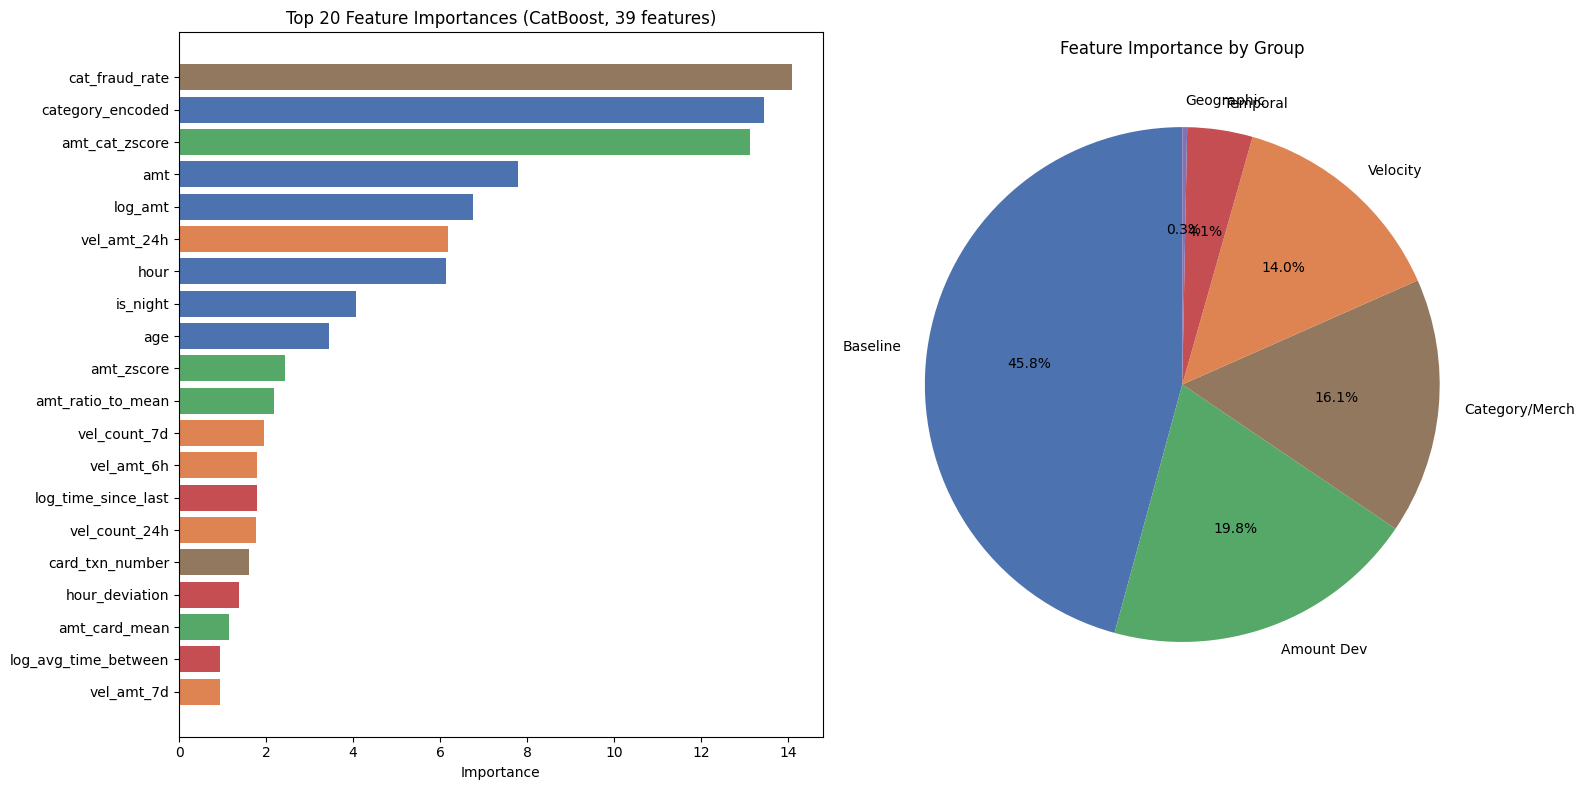

Saved: results/phase3_feature_importance.png


In [17]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 individual features
top20 = feat_imp.head(20)
colors = {'Baseline': '#4C72B0', 'Velocity': '#DD8452', 'Amount Dev': '#55A868',
          'Temporal': '#C44E52', 'Geographic': '#8172B3', 'Category/Merch': '#937860'}
bar_colors = [colors.get(g, 'gray') for g in top20['group']]
axes[0].barh(range(len(top20)), top20['importance'].values, color=bar_colors)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Feature Importances (CatBoost, 39 features)')

# Group-level pie
group_colors = [colors.get(g, 'gray') for g in group_imp.index]
axes[1].pie(group_imp.values, labels=group_imp.index, autopct='%1.1f%%',
            colors=group_colors, startangle=90)
axes[1].set_title('Feature Importance by Group')

plt.tight_layout()
plt.savefig('../results/phase3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase3_feature_importance.png')

## 10. Experiment 3.4: Stacking with LogReg Meta-Learner

Phase 2 found CatBoost and RF have different failure modes (boosters catch 104/141 fraud the other misses, baggers 37/141). Can we exploit this via stacking?

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Generate OOF predictions for stacking (using ALL features)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

oof_cb = np.zeros(len(train))
oof_rf = np.zeros(len(train))
oof_xgb = np.zeros(len(train))
test_cb = np.zeros(len(test))
test_rf = np.zeros(len(test))
test_xgb = np.zeros(len(test))

X_tr = train[ALL_FEATURES].values
X_te = test[ALL_FEATURES].values
y_tr = y_train_arr

print('Generating OOF predictions for stacking (5-fold)...')
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tr, y_tr)):
    print(f'  Fold {fold+1}/5...')
    t0 = time.time()
    
    # CatBoost
    cb = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.1,
                            scale_pos_weight=spw, random_seed=RNG,
                            eval_metric='PRAUC', verbose=0, thread_count=-1)
    cb.fit(X_tr[tr_idx], y_tr[tr_idx])
    oof_cb[va_idx] = cb.predict_proba(X_tr[va_idx])[:, 1]
    test_cb += cb.predict_proba(X_te)[:, 1] / 5
    
    # RF
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight={0:1, 1:5},
                                random_state=RNG, n_jobs=-1)
    rf.fit(X_tr[tr_idx], y_tr[tr_idx])
    oof_rf[va_idx] = rf.predict_proba(X_tr[va_idx])[:, 1]
    test_rf += rf.predict_proba(X_te)[:, 1] / 5
    
    # XGBoost
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         scale_pos_weight=spw, random_state=RNG,
                         eval_metric='aucpr', n_jobs=-1, verbosity=0, tree_method='hist')
    xgb.fit(X_tr[tr_idx], y_tr[tr_idx])
    oof_xgb[va_idx] = xgb.predict_proba(X_tr[va_idx])[:, 1]
    test_xgb += xgb.predict_proba(X_te)[:, 1] / 5
    
    print(f'    done in {time.time()-t0:.1f}s')
    del cb, rf, xgb; gc.collect()

print('OOF predictions complete.')
print(f'OOF CatBoost AUPRC: {average_precision_score(y_tr, oof_cb):.4f}')
print(f'OOF RF AUPRC:       {average_precision_score(y_tr, oof_rf):.4f}')
print(f'OOF XGBoost AUPRC:  {average_precision_score(y_tr, oof_xgb):.4f}')

Generating OOF predictions for stacking (5-fold)...
  Fold 1/5...


    done in 123.8s
  Fold 2/5...


    done in 120.8s
  Fold 3/5...


    done in 124.7s
  Fold 4/5...


    done in 122.3s
  Fold 5/5...


    done in 121.0s
OOF predictions complete.
OOF CatBoost AUPRC: 0.9840
OOF RF AUPRC:       0.9641


OOF XGBoost AUPRC:  0.9852


In [19]:
# Stack with LogReg meta-learner
oof_stack = np.column_stack([oof_cb, oof_rf, oof_xgb])
test_stack = np.column_stack([test_cb, test_rf, test_xgb])

meta = LogisticRegression(random_state=RNG, max_iter=1000)
meta.fit(oof_stack, y_tr)
yp_meta = meta.predict_proba(test_stack)[:, 1]
res_stack = eval_model('Stack(CB+RF+XGB) → LogReg', y_test_arr, yp_meta)
results.append(res_stack)
print(f'Stacked LogReg: AUPRC={res_stack["auprc"]}, F1={res_stack["f1"]}, Prec@95Rec={res_stack["prec@95recall"]}')
print(f'Meta-learner weights: CB={meta.coef_[0][0]:.3f}, RF={meta.coef_[0][1]:.3f}, XGB={meta.coef_[0][2]:.3f}')

# Also try simple average
yp_avg = (test_cb + test_rf + test_xgb) / 3
res_avg = eval_model('Simple Average(CB+RF+XGB)', y_test_arr, yp_avg)
results.append(res_avg)
print(f'Simple Average: AUPRC={res_avg["auprc"]}, F1={res_avg["f1"]}')

# Weighted by OOF AUPRC
w_cb = average_precision_score(y_tr, oof_cb)
w_rf = average_precision_score(y_tr, oof_rf)
w_xgb = average_precision_score(y_tr, oof_xgb)
w_total = w_cb + w_rf + w_xgb
yp_wavg = (test_cb * w_cb + test_rf * w_rf + test_xgb * w_xgb) / w_total
res_wavg = eval_model('Weighted Avg(CB+RF+XGB)', y_test_arr, yp_wavg)
results.append(res_wavg)
print(f'Weighted Average: AUPRC={res_wavg["auprc"]}, F1={res_wavg["f1"]}')

Stacked LogReg: AUPRC=0.9822, F1=0.9364, Prec@95Rec=0.9323
Meta-learner weights: CB=5.213, RF=3.457, XGB=5.158


Simple Average: AUPRC=0.9815, F1=0.939


Weighted Average: AUPRC=0.9816, F1=0.9395


## 11. Grand Comparison Table

In [20]:
all_results_df = pd.DataFrame(results).sort_values('auprc', ascending=False).reset_index(drop=True)
all_results_df.index += 1
all_results_df.index.name = 'Rank'
print('='*100)
print('PHASE 3 GRAND COMPARISON (sorted by AUPRC)')
print('='*100)
print(all_results_df.to_string())

# Phase 2 champion comparison
p2_champion = 0.8872  # CatBoost Phase 2
best = all_results_df.iloc[0]
print(f'\n>>> Phase 2 champion: CatBoost AUPRC=0.8872')
print(f'>>> Phase 3 champion: {best["model"]} AUPRC={best["auprc"]} (Δ={best["auprc"]-p2_champion:+.4f})')

PHASE 3 GRAND COMPARISON (sorted by AUPRC)
                           model   auprc  roc_auc      f1  precision  recall  prec@95recall  train_time_s
Rank                                                                                                     
1     CatBoost (39 all features)  0.9824   0.9998  0.9462     0.9638  0.9293         0.9260         35.91
2      Stack(CB+RF+XGB) → LogReg  0.9822   0.9996  0.9364     0.9837  0.8934         0.9323           NaN
3        Weighted Avg(CB+RF+XGB)  0.9816   0.9995  0.9395     0.9810  0.9013         0.9323           NaN
4      Simple Average(CB+RF+XGB)  0.9815   0.9995  0.9390     0.9810  0.9004         0.9323           NaN
5      XGBoost (39 all features)  0.9785   0.9997  0.9323     0.9510  0.9144         0.8824          2.34
6           RF (39 all features)  0.9639   0.9984  0.8705     0.9933  0.7747         0.8086        111.48
7               RF (17 baseline)  0.8895   0.9917  0.8043     0.9763  0.6838         0.2203         41.62
8  

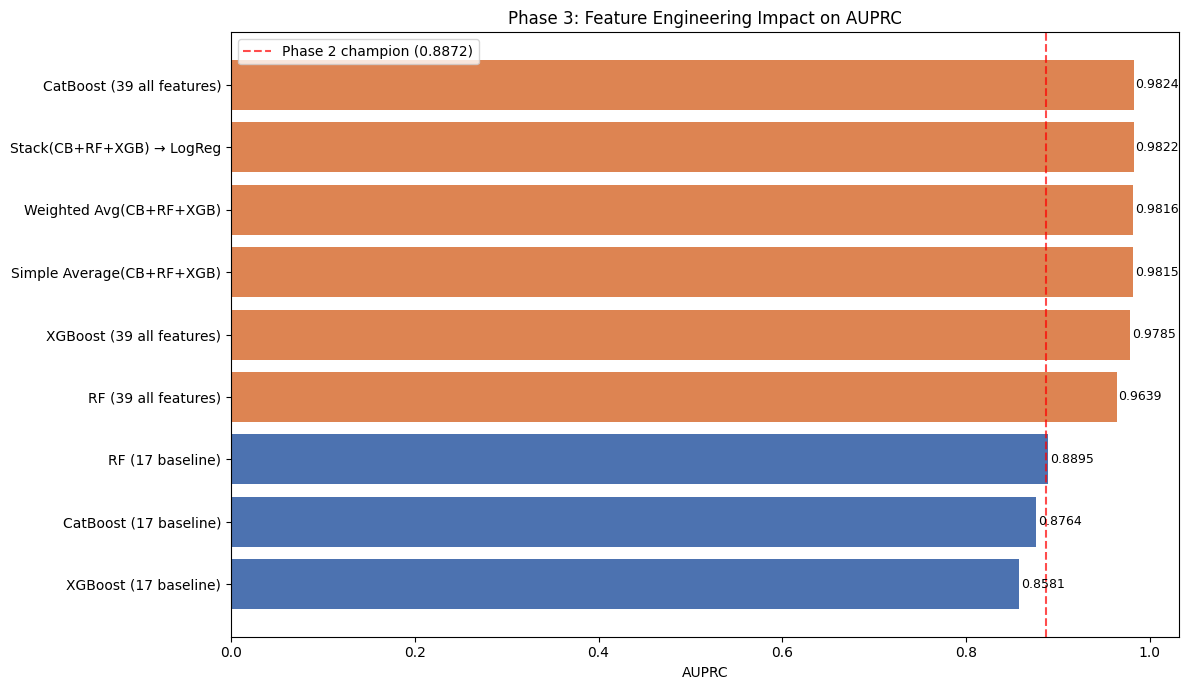

Saved: results/phase3_model_comparison.png


In [21]:
# Save comparison chart
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = all_results_df.sort_values('auprc', ascending=True)
bar_colors_list = []
for m in plot_df['model']:
    if '39' in m or 'Stack' in m or 'Average' in m or 'Weighted' in m:
        bar_colors_list.append('#DD8452')  # new features / ensemble
    else:
        bar_colors_list.append('#4C72B0')  # baseline

ax.barh(range(len(plot_df)), plot_df['auprc'].values, color=bar_colors_list)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['model'].values)
ax.set_xlabel('AUPRC')
ax.set_title('Phase 3: Feature Engineering Impact on AUPRC')
ax.axvline(x=p2_champion, color='red', linestyle='--', alpha=0.7, label=f'Phase 2 champion ({p2_champion})')
ax.legend()

for i, v in enumerate(plot_df['auprc'].values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/phase3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase3_model_comparison.png')

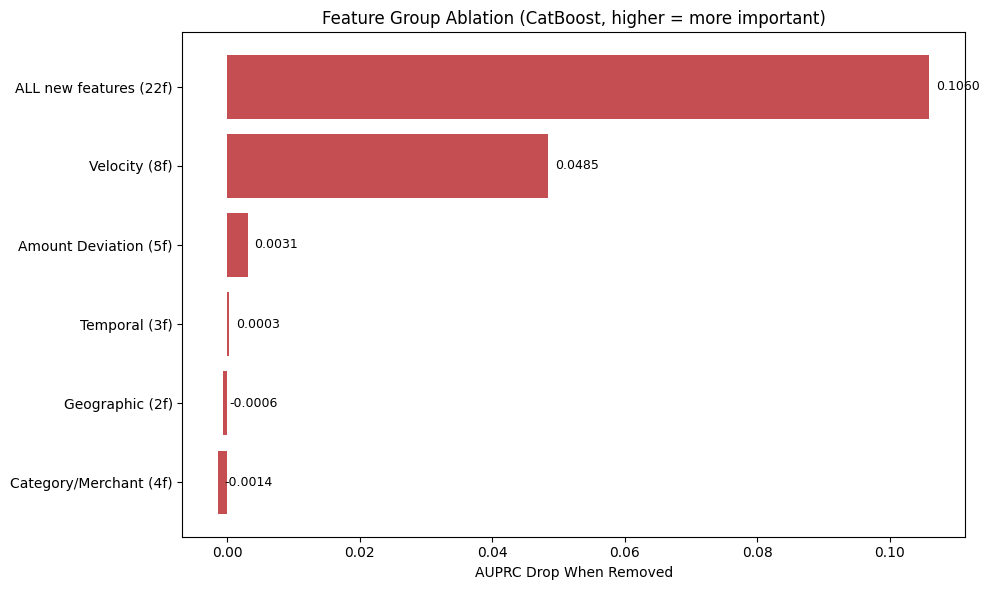

Saved: results/phase3_ablation.png


In [22]:
# Save ablation chart
fig, ax = plt.subplots(figsize=(10, 6))
abl_sorted = abl_df.sort_values('AUPRC Drop', ascending=True)
ax.barh(range(len(abl_sorted)), abl_sorted['AUPRC Drop'].values, color='#C44E52')
ax.set_yticks(range(len(abl_sorted)))
ax.set_yticklabels([f"{r['Group Removed']} ({r['N Features Removed']}f)" for _, r in abl_sorted.iterrows()])
ax.set_xlabel('AUPRC Drop When Removed')
ax.set_title('Feature Group Ablation (CatBoost, higher = more important)')

for i, v in enumerate(abl_sorted['AUPRC Drop'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/phase3_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase3_ablation.png')

## 12. Save Results

In [23]:
# Update metrics.json
metrics_path = Path('../results/metrics.json')
metrics = json.loads(metrics_path.read_text())

metrics['anthony_phase3'] = {
    'phase': 3,
    'date': '2026-04-29',
    'researcher': 'Anthony Rodrigues',
    'primary_metric': 'AUPRC',
    'n_baseline_features': len(BASELINE_FEATURES),
    'n_new_features': len(ALL_NEW_FEATURES),
    'n_total_features': len(ALL_FEATURES),
    'feature_groups': {
        'velocity': VELOCITY_FEATURES,
        'amount_deviation': AMOUNT_DEV_FEATURES,
        'temporal': TEMPORAL_FEATURES,
        'geographic': GEO_FEATURES,
        'category_merchant': CATEGORY_FEATURES,
    },
    'model_comparison': results,
    'ablation': ablation_results,
    'feature_importance_top10': feat_imp.head(10).to_dict('records'),
}

metrics_path.write_text(json.dumps(metrics, indent=2))
print(f'Saved metrics to {metrics_path}')
print(f'Total experiments this phase: {len(results)}')

Saved metrics to ../results/metrics.json
Total experiments this phase: 9


## Key Findings Summary

In [24]:
print('='*80)
print('PHASE 3 KEY FINDINGS')
print('='*80)
print()
print('1. FEATURE ENGINEERING IMPACT:')
for model_name in ['CatBoost', 'RF', 'XGBoost']:
    rows = [r for r in results if model_name in r['model']]
    if len(rows) >= 2:
        base_r = [r for r in rows if '17' in r['model']][0]
        full_r = [r for r in rows if '39' in r['model']][0]
        delta = full_r['auprc'] - base_r['auprc']
        print(f'   {model_name}: {base_r["auprc"]} → {full_r["auprc"]} (Δ={delta:+.4f})')

print(f'\n2. ABLATION (most impactful feature group):')
top_group = abl_df.iloc[0]
print(f'   {top_group["Group Removed"]}: removing it drops AUPRC by {top_group["AUPRC Drop"]} ({top_group["Drop %"]})')

print(f'\n3. STACKING:')
print(f'   LogReg stack: AUPRC={res_stack["auprc"]}')
print(f'   Simple avg:   AUPRC={res_avg["auprc"]}')
print(f'   Weighted avg: AUPRC={res_wavg["auprc"]}')

print(f'\n4. TOP 5 FEATURES:')
for _, row in feat_imp.head(5).iterrows():
    print(f'   {row["feature"]:30s} ({row["group"]:15s}): {row["importance"]:.2f}')

best = all_results_df.iloc[0]
print(f'\n5. PHASE 3 CHAMPION: {best["model"]} — AUPRC={best["auprc"]}')
print(f'   vs Phase 2 champion (CatBoost 17f): Δ={best["auprc"]-0.8872:+.4f}')

PHASE 3 KEY FINDINGS

1. FEATURE ENGINEERING IMPACT:
   CatBoost: 0.8764 → 0.9824 (Δ=+0.1060)
   RF: 0.8895 → 0.9639 (Δ=+0.0744)
   XGBoost: 0.8581 → 0.9785 (Δ=+0.1204)

2. ABLATION (most impactful feature group):
   ALL new features: removing it drops AUPRC by 0.106 (10.79%)

3. STACKING:
   LogReg stack: AUPRC=0.9822
   Simple avg:   AUPRC=0.9815
   Weighted avg: AUPRC=0.9816

4. TOP 5 FEATURES:
   cat_fraud_rate                 (Category/Merch ): 14.09
   category_encoded               (Baseline       ): 13.45
   amt_cat_zscore                 (Amount Dev     ): 13.12
   amt                            (Baseline       ): 7.79
   log_amt                        (Baseline       ): 6.75

5. PHASE 3 CHAMPION: CatBoost (39 all features) — AUPRC=0.9824
   vs Phase 2 champion (CatBoost 17f): Δ=+0.0952
